# Use scoring_bot env
# Used to tally points from extracted WhatsApp chat

In [1]:
import pandas as pd
import polars as pl
import re
from wordle_bot.whatsapp import Database
from wordle_bot.scorer import ScoreCalculator as SC
from wordle_bot.whatsapp import df_to_whatsapp_score_rank, df_to_whatsapp_overall_score_rank
from datetime import datetime
import wordle_bot.parser as parser
import sqlite3
from wordle_bot.database import Database_wordle as DW
import matplotlib.pyplot as plt

In [2]:
with open('WhatsApp Chat with Wordle Golf example.txt', 'r', encoding = 'utf-8') as f:
    lines = f.readlines()

for line in lines[80:120]:
    print(line.strip())

⬜🟩🟩🟩⬜
⬜🟩🟩🟩🟩
🟩🟩🟩🟩🟩
1/25/26, 8:48 PM - A: Wordle 1,682 4/6*

🟩⬛⬛⬛⬛
🟩🟩⬛🟨⬛
🟩🟩🟨⬛🟨
🟩🟩🟩🟩🟩
1/25/26, 11:50 PM - M: Wordle 1682 5/6*

⬛⬛🟨⬛🟨
⬛⬛🟩🟩🟨
⬛🟩🟩🟩⬛
⬛🟩🟩🟩🟩
🟩🟩🟩🟩🟩
1/26/26, 12:43 AM - C: Wordle 1,682 4/6

⬛🟩🟨⬛🟨
⬛🟩🟩🟩⬛
⬛🟩🟩🟩🟩
🟩🟩🟩🟩🟩
1/26/26, 12:44 AM - C: I feel like we made the same conclusion 🤣
1/26/26, 2:19 AM - D: Wordle 1,682 4/6*

⬜🟩🟨⬜🟨
🟨🟩🟩⬜⬜
⬜🟩🟩🟩⬜
🟩🟩🟩🟩🟩
1/26/26, 3:14 AM - P: Wordle 1,682 2/6*

🟨🟨⬛⬛🟨
🟩🟩🟩🟩🟩
1/26/26, 3:15 AM - Z: Wordle 1,682 4/6*

🟨⬛⬛⬛⬛
⬛⬛🟨🟩⬛
⬛⬛⬛🟩🟨
🟩🟩🟩🟩🟩
1/26/26, 11:29 AM - H: Wordle 1,682 4/6*


In [3]:
result_lines = parser.parser_wordle_score(lines)
print(result_lines[:5])

[('M', 1681, '3'), ('Z', 1681, '3'), ('P', 1681, '3'), ('C', 1681, '3'), ('A', 1681, '5')]


In [4]:
scores_extract = [SC(player, wordle, score) for player, wordle, score in result_lines]

In [5]:
print(scores_extract[:5])

[(player=M, wordle=1681, score=3)
, (player=Z, wordle=1681, score=3)
, (player=P, wordle=1681, score=3)
, (player=C, wordle=1681, score=3)
, (player=A, wordle=1681, score=5)
]


In [6]:
# Save scores to database
db = DW("scores.db")

for line in scores_extract:
    exists = db.conn.execute(
        """
        SELECT 1 FROM scores 
        WHERE player = ? AND wordle= ?
        """,
        (line.player, line.wordle_num)
    ).fetchone() # returns None if no row exists

    if not exists:
        db.save_score_if_missing_or_7(line.player, line.wordle_num, line.score)



In [7]:
# Read scores from database and convert to DataFrame
scores_extract2 = db.load_scores(wordle_num=None, wordle_min=None, wordle_max=1710)

print(scores_extract2)

shape: (235, 3)
┌────────┬────────────┬───────┐
│ player ┆ wordle_num ┆ score │
│ ---    ┆ ---        ┆ ---   │
│ str    ┆ i64        ┆ str   │
╞════════╪════════════╪═══════╡
│ D      ┆ 1681       ┆ 3     │
│ H      ┆ 1681       ┆ 5     │
│ J      ┆ 1682       ┆ 4     │
│ A      ┆ 1682       ┆ 4     │
│ M      ┆ 1682       ┆ 5     │
│ …      ┆ …          ┆ …     │
│ Z      ┆ 1681       ┆ 3     │
│ P      ┆ 1681       ┆ 3     │
│ C      ┆ 1681       ┆ 3     │
│ A      ┆ 1681       ┆ 5     │
│ J      ┆ 1681       ┆ 5     │
└────────┴────────────┴───────┘


In [8]:
# run score cleaner on new extracts
df = SC.score_cleaner(scores_extract)
print(df)

shape: (1_385, 3)
┌────────┬────────────┬───────┐
│ player ┆ wordle_num ┆ score │
│ ---    ┆ ---        ┆ ---   │
│ str    ┆ i64        ┆ i64   │
╞════════╪════════════╪═══════╡
│ A      ┆ 1681       ┆ 5     │
│ C      ┆ 1681       ┆ 3     │
│ D      ┆ 1681       ┆ 3     │
│ H      ┆ 1681       ┆ 5     │
│ J      ┆ 1681       ┆ 5     │
│ …      ┆ …          ┆ …     │
│ H      ┆ 1853       ┆ null  │
│ J      ┆ 1853       ┆ null  │
│ M      ┆ 1853       ┆ 5     │
│ P      ┆ 1853       ┆ null  │
│ Z      ┆ 1853       ┆ null  │
└────────┴────────────┴───────┘


In [9]:
print(df)

shape: (1_385, 3)
┌────────┬────────────┬───────┐
│ player ┆ wordle_num ┆ score │
│ ---    ┆ ---        ┆ ---   │
│ str    ┆ i64        ┆ i64   │
╞════════╪════════════╪═══════╡
│ A      ┆ 1681       ┆ 5     │
│ C      ┆ 1681       ┆ 3     │
│ D      ┆ 1681       ┆ 3     │
│ H      ┆ 1681       ┆ 5     │
│ J      ┆ 1681       ┆ 5     │
│ …      ┆ …          ┆ …     │
│ H      ┆ 1853       ┆ null  │
│ J      ┆ 1853       ┆ null  │
│ M      ┆ 1853       ┆ 5     │
│ P      ┆ 1853       ┆ null  │
│ Z      ┆ 1853       ┆ null  │
└────────┴────────────┴───────┘


In [10]:
weekly_scores = SC.week_ranking(df)
print(weekly_scores)

[shape: (8, 4)
┌────────┬───────┬─────────────┬──────┐
│ player ┆ score ┆ wordle_week ┆ rank │
│ ---    ┆ ---   ┆ ---         ┆ ---  │
│ str    ┆ i64   ┆ str         ┆ f64  │
╞════════╪═══════╪═════════════╪══════╡
│ P      ┆ 25    ┆ 1681-1687   ┆ 2.0  │
│ A      ┆ 25    ┆ 1681-1687   ┆ 2.0  │
│ C      ┆ 25    ┆ 1681-1687   ┆ 2.0  │
│ M      ┆ 26    ┆ 1681-1687   ┆ 4.0  │
│ Z      ┆ 28    ┆ 1681-1687   ┆ 5.0  │
│ D      ┆ 29    ┆ 1681-1687   ┆ 6.0  │
│ H      ┆ 30    ┆ 1681-1687   ┆ 7.0  │
│ J      ┆ 31    ┆ 1681-1687   ┆ 8.0  │
└────────┴───────┴─────────────┴──────┘, shape: (8, 4)
┌────────┬───────┬─────────────┬──────┐
│ player ┆ score ┆ wordle_week ┆ rank │
│ ---    ┆ ---   ┆ ---         ┆ ---  │
│ str    ┆ i64   ┆ str         ┆ f64  │
╞════════╪═══════╪═════════════╪══════╡
│ H      ┆ 28    ┆ 1688-1694   ┆ 1.5  │
│ P      ┆ 28    ┆ 1688-1694   ┆ 1.5  │
│ M      ┆ 30    ┆ 1688-1694   ┆ 4.5  │
│ J      ┆ 30    ┆ 1688-1694   ┆ 4.5  │
│ Z      ┆ 30    ┆ 1688-1694   ┆ 4.5  │
│ C      ┆

In [11]:
# def running_ranking(weekly_scores, interest="overall_rank"):
#         """
        
#         weekly_scores: list of polars DataFrames, each representing a week's scores
#         returns list of polars DataFrames with an additional column 'overall_rank' and 'overall_score' representing the cumulative rank and score across all weeks
#         """

#         cumulative_rank = {}
#         cumulative_score = {}
        
#         ranked_weeks = []

#         for week in weekly_scores:
#                 # Compute this week's rank contribution
#                 week_rank = (
#                     week.group_by("player")
#                         .agg(pl.sum("rank").alias("week_rank"))
#                 )

#                 # Update cumulative totals
#                 for row in week_rank.iter_rows(named=True):
#                     player = row["player"]
#                     cumulative_rank[player] = cumulative_rank.get(player, 0) + row["week_rank"]

#                 # Compute this week's score contribution
#                 week_score = (
#                     week.group_by("player")
#                         .agg(pl.sum("score").alias("week_score"))
#                 )

#                 # Update cumulative totals
#                 for row in week_score.iter_rows(named=True):
#                     player = row["player"]
#                     cumulative_score[player] = cumulative_score.get(player, 0) + row["week_score"]

#                 # Convert cumulative dict → Polars DF
#                 cumulative_df = pl.DataFrame(
#                     {"player": list(cumulative_rank.keys()),
#                      "overall_rank": list(cumulative_rank.values())}
#                 )

#                 cumulative_score_df = pl.DataFrame(
#                     {"player": list(cumulative_score.keys()),
#                      "overall_score": list(cumulative_score.values())}
#                 )

#                 # Join cumulative rank into this week's DF
#                 week_with_running = (
#                     week.join(cumulative_df, on="player", how="left")
#                     .join(cumulative_score_df, on="player", how="left")
#                     .with_columns([
#                           pl.col("overall_rank").cast(pl.Float64), 
#                           pl.col("overall_score").cast(pl.Float64)])
#                         .sort(interest)
#                 )

#                 ranked_weeks.append(week_with_running)
                
#         # ranked_weeks[-1] = ranked_weeks[-1].sort(interest)

#         return ranked_weeks

In [12]:
overall_score = SC.running_ranking(weekly_scores, interest="overall_score")
print(overall_score[-1])

shape: (8, 6)
┌────────┬───────┬─────────────┬──────┬──────────────┬───────────────┐
│ player ┆ score ┆ wordle_week ┆ rank ┆ overall_rank ┆ overall_score │
│ ---    ┆ ---   ┆ ---         ┆ ---  ┆ ---          ┆ ---           │
│ str    ┆ i64   ┆ str         ┆ f64  ┆ f64          ┆ f64           │
╞════════╪═══════╪═════════════╪══════╪══════════════╪═══════════════╡
│ C      ┆ 18    ┆ 1849-1855   ┆ 4.5  ┆ 74.5         ┆ 673.0         │
│ M      ┆ 22    ┆ 1849-1855   ┆ 7.0  ┆ 82.5         ┆ 697.0         │
│ H      ┆ 19    ┆ 1849-1855   ┆ 6.0  ┆ 105.5        ┆ 715.0         │
│ A      ┆ 23    ┆ 1849-1855   ┆ 8.0  ┆ 115.0        ┆ 731.0         │
│ J      ┆ 18    ┆ 1849-1855   ┆ 4.5  ┆ 121.5        ┆ 740.0         │
│ Z      ┆ 16    ┆ 1849-1855   ┆ 1.5  ┆ 134.0        ┆ 750.0         │
│ D      ┆ 17    ┆ 1849-1855   ┆ 3.0  ┆ 132.0        ┆ 755.0         │
│ P      ┆ 16    ┆ 1849-1855   ┆ 1.5  ┆ 135.0        ┆ 779.0         │
└────────┴───────┴─────────────┴──────┴──────────────┴─────────

shape: (200, 6)
┌────────┬───────┬─────────────┬──────┬──────────────┬───────────────┐
│ player ┆ score ┆ wordle_week ┆ rank ┆ overall_rank ┆ overall_score │
│ ---    ┆ ---   ┆ ---         ┆ ---  ┆ ---          ┆ ---           │
│ str    ┆ i64   ┆ str         ┆ f64  ┆ f64          ┆ f64           │
╞════════╪═══════╪═════════════╪══════╪══════════════╪═══════════════╡
│ P      ┆ 25    ┆ 1681-1687   ┆ 2.0  ┆ 2.0          ┆ 25.0          │
│ A      ┆ 25    ┆ 1681-1687   ┆ 2.0  ┆ 2.0          ┆ 25.0          │
│ C      ┆ 25    ┆ 1681-1687   ┆ 2.0  ┆ 2.0          ┆ 25.0          │
│ M      ┆ 26    ┆ 1681-1687   ┆ 4.0  ┆ 4.0          ┆ 26.0          │
│ Z      ┆ 28    ┆ 1681-1687   ┆ 5.0  ┆ 5.0          ┆ 28.0          │
│ …      ┆ …     ┆ …           ┆ …    ┆ …            ┆ …             │
│ A      ┆ 23    ┆ 1849-1855   ┆ 8.0  ┆ 115.0        ┆ 731.0         │
│ J      ┆ 18    ┆ 1849-1855   ┆ 4.5  ┆ 121.5        ┆ 740.0         │
│ Z      ┆ 16    ┆ 1849-1855   ┆ 1.5  ┆ 134.0        ┆ 750.0 

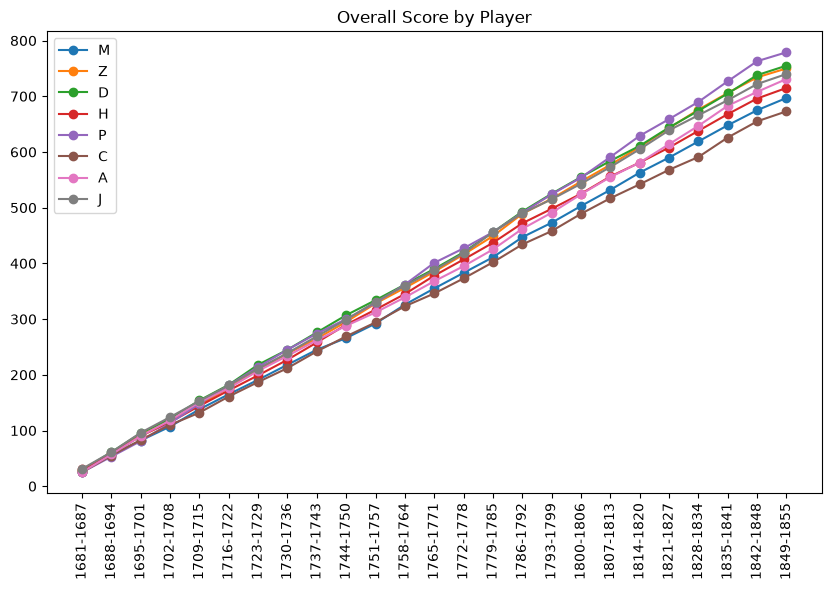

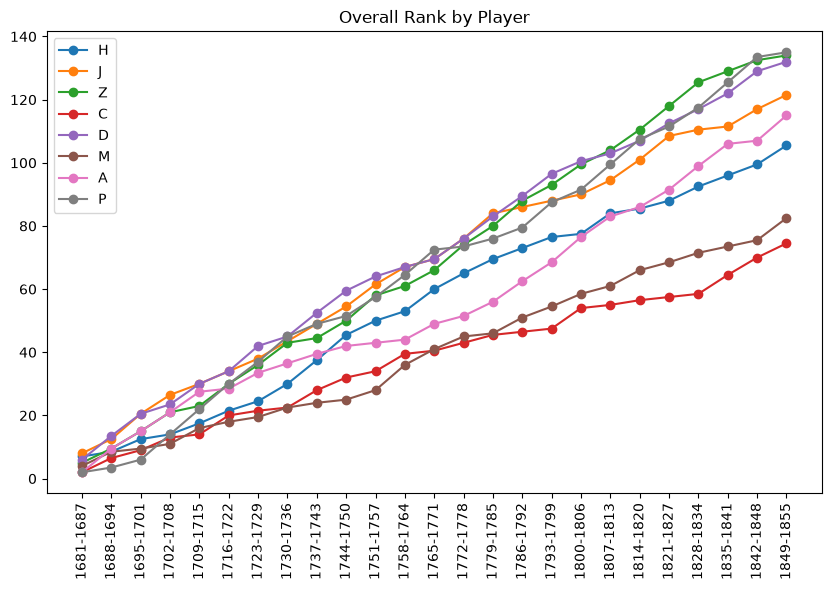

In [13]:
overall_score_concat = pl.concat(overall_score)

print(overall_score_concat)

plt.figure(figsize=(10, 6))
for player in overall_score_concat['player'].unique():
    player_scores = overall_score_concat.filter(pl.col("player") == player)
    plt.plot(player_scores['wordle_week'], player_scores['overall_score'], marker='o', label=player)
    plt.legend()
    plt.title('Overall Score by Player')
    plt.xticks(rotation=90)

plt.figure(figsize=(10, 6))
for player in overall_score_concat['player'].unique():
    player_scores = overall_score_concat.filter(pl.col("player") == player)
    plt.plot(player_scores['wordle_week'], player_scores['overall_rank'], marker='o', label=player)
    plt.legend()
    plt.title('Overall Rank by Player')
    plt.xticks(rotation=90)

In [19]:

text = df_to_whatsapp_score_rank(overall_score[-1])
print(f'{text} \n')

text1 = df_to_whatsapp_overall_score_rank(overall_score[-1])
print(text1)

Player    Week      Score   Rank
C      1849-1855      18   4.5
M      1849-1855      22   7.0
H      1849-1855      19   6.0
A      1849-1855      23   8.0
J      1849-1855      18   4.5
Z      1849-1855      16   1.5
D      1849-1855      17   3.0
P      1849-1855      16   1.5 

Player  AT Score  AT Rank
C           673.0     74.5
M           697.0     82.5
H           715.0    105.5
A           731.0    115.0
J           740.0    121.5
Z           750.0    134.0
D           755.0    132.0
P           779.0    135.0


In [15]:
# db = Database()

# for result in result_lines:
#     date, player, wordle, score = result
#     db.save_score(date, player, wordle, score)



In [16]:
get_scores = db.leaderboard()
print(get_scores)

AttributeError: 'Database_wordle' object has no attribute 'leaderboard'